# Incorrect array initialization


If you pass the following list [1, (2, 3), 4] to initialize a NumPy array, what would be the data type of the stored values?


In [2]:
import numpy as np

x = np.array([1, (2, 3), 4] )
print(type(x))
print(x.dtype)

<class 'numpy.ndarray'>
object


C:\Users\88016\AppData\Local\Temp/ipykernel_10520/3148398273.py:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.array([1, (2, 3), 4] )


# Accessing subarrays


Let's access elements in NumPy arrays! Your task is to convert a square two-dimensional array square of size size to a list created by following a spiral pattern:

<center><img src="images/04.01.png"  style="width: 400px, height: 300px;"/></center>


In [4]:
import numpy as np
square = [[ 1,  2,  3,  4,  5],
 [ 6,  7,  8,  9, 10],
 [11, 12, 13, 14, 15],
 [16, 17, 18, 19, 20],
 [21, 22, 23, 24, 25]]
square = np.array(square)
size = 5

spiral = []

for i in range(0, size):
    # Convert each part marked by any red arrow to a list
    spiral += list(square[i, i:size-i])
    # Convert each part marked by any green arrow to a list
    spiral += list(square[i+1:size, size-i-1])
    # Convert each part marked by any blue arrow to a list
    spiral += list(reversed(square[size-i-1, i:size-i-1]))
    # Convert each part marked by any magenta arrow to a list
    spiral += list(reversed(square[i+1:size-i-1, i]))
        
print(spiral)


[1, 2, 3, 4, 5, 10, 15, 20, 25, 24, 23, 22, 21, 16, 11, 6, 7, 8, 9, 14, 19, 24, 18, 17, 12, 13, 18, 23, 22]


# Operations with NumPy arrays


The following blocks of code create new lists given input lists input_list1, input_list2, input_list3 (you can check their values in the console). If you had analogous NumPy arrays with the same values input_array1, input_array2, input_array3 (you can check their values in the console), how would you create similar output as NumPy arrays using the knowledge on broadcasting, accessing element in NumPy arrays, and performing element-wise operations?

- Block 1 = `list(map(lambda x: [5*i for i in x], input_list1))`
- Block 2 = `list(filter(lambda x: x % 2 == 0, input_list2))`
- Block 3 = `[[i*i for i in j] for j in input_list3]`


In [5]:
input_array1 = np.array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

input_array2 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
input_array3 = np.array([[1, 2],
       [3, 4],
       [5, 6]])
input_list1 = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
input_list2 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
input_list3 = [[1, 2], [3, 4], [5, 6]]


# Substitute the code in the block 1 given the input_array1
output_array1 = list(map(lambda x: [5*i for i in x], input_array1))
print(list(map(lambda x: [5*i for i in x], input_list1)))
print(output_array1)

# Substitute the code in the block 2 given the input_array2
output_array2 = list(filter(lambda x: x % 2 == 0, input_array2))
print(list(filter(lambda x: x % 2 == 0, input_list2)))
print(output_array2)

# Substitute the code in the block 3 given the input_array3
output_array3 = [[i*i for i in j] for j in input_array3]
print([[i*i for i in j] for j in input_list3])
print(output_array3)

[[5, 10, 15], [20, 25, 30], [35, 40, 45]]
[[5, 10, 15], [20, 25, 30], [35, 40, 45]]
[0, 2, 4, 6, 8]
[0, 2, 4, 6, 8]
[[1, 4], [9, 16], [25, 36]]
[[1, 4], [9, 16], [25, 36]]


# Simple use of .apply()


Let's get some handful experience with .apply()!

You are given the full scores dataset containing students' performance as well as their background information.


In [7]:
import pandas as pd
from functools import reduce
scores = pd.read_csv("dataset/exams.csv")
groups_to_consider = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
def prevalence(series):
    vals = list(series)
    # Create a tuple list with unique items and their counts
    itms = [(x, vals.count(x)) for x in set(series)]
    # Extract a tuple with the highest counts using reduce()
    res = reduce(lambda x, y: x if x[1] > y[1] else y, itms)
    # Return the item with the highest counts
    return res[0]

# Apply the prevalence function on the scores DataFrame
result = scores[groups_to_consider].apply(prevalence)
print(result)

gender                               female
race/ethnicity                      group C
parental level of education    some college
lunch                              standard
test preparation course                none
dtype: object


# Additional arguments


To accomplish this task, you'll need to define the function rank that, given a series, returns a list with two values: the mean of the series and a string defined by the aforementioned rule.


In [8]:
def rank(series):
    # Calculate the mean of the input series
    mean = series.mean()
    # Return the mean and its rank as a list
    if mean > 90:
        return [mean, 'high']
    if mean > 60 and mean <= 90:
        return [mean, 'medium']
    return [mean, 'low']

# Insert the output of rank() into new columns of scores
cols = ['math score', 'reading score', 'writing score']
scores[['mean', 'rank']] = scores[cols].apply(rank, axis=1, result_type='expand')
print(scores[['mean', 'rank']].head())

        mean    rank
0  80.666667  medium
1  48.666667     low
2  47.666667     low
3  91.666667    high
4  82.333333  medium


# Functions with additional arguments


Let's add some arguments to the function definition!

Numeric data in scores represent students' performance scaled between 0 and 100. Your task is to rescale this data to an arbitrary range between low and high. Rescaling should be done in a linear fashion


In [9]:
def rescale(series, low, high):
   # Define the expression to rescale input series
   return series*(high-low)/100 + low

# Rescale the data in cols to lie between 1 and 10
cols = ['math score', 'reading score', 'writing score'] 
scores[cols] = scores[cols].apply(rescale, args=[1, 10])
print(scores[cols].head())

   math score  reading score  writing score
0        7.66           8.74           8.38
1        4.96           5.41           5.77
2        5.86           5.14           4.87
3        8.92           9.55           9.28
4        8.65           8.29           8.29


In [10]:
# Redefine the function to accept keyword arguments
def rescale(series, high=100, low=0):
   return series * (high - low)/100 + low

# Rescale the data in cols to lie between 1 and 10
cols = ['math score', 'reading score', 'writing score']
scores[cols] = scores[cols].apply(rescale, low=1, high=10)
print(scores[cols].head())

   math score  reading score  writing score
0      1.6894         1.7866         1.7542
1      1.4464         1.4869         1.5193
2      1.5274         1.4626         1.4383
3      1.8028         1.8595         1.8352
4      1.7785         1.7461         1.7461


# Standard DataFrame methods


You are given the diabetes dataset storing information on female patients tested for diabetes. You will focus on blood glucose levels and the test results. Subjects, tested positively, usually have higher blood glucose levels after performing the so-called glucose tolerance test. Your task is to investigate whether it is true for this specific dataset.


In [11]:
# Load the data from the diabetes.csv file
diabetes = pd.read_csv("dataset/diabetes.csv")
print(diabetes.info())

# Calculate the mean glucose level in the entire dataset
print(diabetes["plasma glucose"].mean())

# Group the data according to the diabetes test results
diabetes_grouped = diabetes.groupby("test result")

# Calculate the mean glucose levels per group
print(diabetes_grouped["plasma glucose"].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   n pregnant         768 non-null    int64  
 1   plasma glucose     763 non-null    float64
 2   blood pressure     733 non-null    float64
 3   skin thickness     541 non-null    float64
 4   serum insulin      394 non-null    float64
 5   bmi                757 non-null    float64
 6   pedigree function  768 non-null    float64
 7   age                768 non-null    int64  
 8   test result        768 non-null    object 
dtypes: float64(6), int64(2), object(1)
memory usage: 54.1+ KB
None
121.6867627785059
test result
negative    110.643863
positive    142.319549
Name: plasma glucose, dtype: float64


# BMI of villains


Let's return to the heroes dataset containing the information on different comic book heroes. We added a bmi column to the dataset calculated as Weight divided by (Height/100)\*\*2. This index helps define whether an individual has weight problems.


In [15]:
import numpy as np
heroes = pd.read_csv("dataset/heroes_information.csv")
heroes["bmi"] = heroes['Weight'] /  (heroes['Height'] / 100)**2
print(heroes.columns)
heroes.head()

Index(['Unnamed: 0', 'name', 'Gender', 'Eye color', 'Race', 'Hair color',
       'Height', 'Publisher', 'Skin color', 'Alignment', 'Weight', 'bmi'],
      dtype='object')


,Unnamed: 0,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight,bmi
0,0,A-Bomb,Male,yellow,Human,No Hair,203.0,Marvel Comics,-,good,441.0,107.015458
1,1,Abe Sapien,Male,blue,Icthyo Sapien,No Hair,191.0,Dark Horse Comics,blue,good,65.0,17.817494
2,2,Abin Sur,Male,blue,Ungaran,No Hair,185.0,DC Comics,red,good,90.0,26.296567
3,3,Abomination,Male,green,Human / Radiation,No Hair,203.0,Marvel Comics,-,bad,441.0,107.015458
4,4,Abraxas,Male,blue,Cosmic Entity,Black,-99.0,Marvel Comics,-,bad,-99.0,-101.010101


In [16]:
# Group the data by two factors specified in the context
groups = heroes.groupby(['Publisher', 'Alignment'])

# Filter groups having more than 10 valid bmi observations
fheroes = groups.filter(lambda x: x['bmi'].count() > 10)

# Group the filtered data again by the same factors
fgroups = fheroes.groupby(['Publisher', 'Alignment'])

# Calculate the mean and standard deviation of the BMI index
result = fgroups['bmi'].agg([np.mean, np.std])
print(result)

                                   mean         std
Publisher         Alignment                        
DC Comics         bad         13.121538  223.552122
                  good       -15.353158   59.322142
                  neutral    -17.856179   69.314656
Dark Horse Comics good       -17.905567   61.631452
Image Comics      bad       -101.010101    0.000000
Marvel Comics     bad         23.576160  260.314675
                  good         7.493435   50.359506
                  neutral     24.076486   73.907059
NBC - Heroes      good      -101.010101    0.000000


# NaN value imputation


Let's try to impute some values, using the .transform() method. In the previous task you created a DataFrame fheroes where all the groups with insufficient amount of bmi observations were removed. Our bmi column has a lot of missing values (NaNs) though. Given two copies of the fheroes DataFrame (imp_globmean and imp_grpmean), your task is to impute the NaNs in the bmi column with the overall mean value and with the mean value per group defined by Publisher and Alignment factors, respectively.


In [21]:
# # Define a lambda function that imputes NaN values in series
# impute = lambda series: series.fillna(series.mean())

# # Impute NaNs in the bmi column of imp_globmean
# imp_globmean['bmi'] = imp_globmean['bmi'].transform(impute)
# print("Global mean = " + str(fheroes['bmi'].mean()) + "\n")

# groups = imp_grpmean.groupby(['Publisher', 'Alignment'])

# # Impute NaNs in the bmi column of imp_grpmean
# imp_grpmean['bmi'] = groups['bmi'].transform(impute)
# print(groups['bmi'].mean())

# Explore feature relationships


Let's do some exploratory analysis. You are already familiar with the retinol dataset. It stores the information on the relationship between different factors (background information, clinical data) and the levels of retinol (plasma retinol) and beta-carotene (plasma B-carotene) in blood plasma. Low levels of these compounds were reported to be associated with higher risk of cancer.


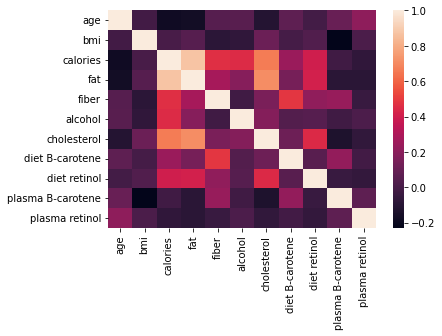

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
retinol = pd.read_csv("dataset/retinol.csv")
sns.heatmap(retinol.corr()) # ,annot=True
plt.show()

# Plot a histogram


Let's further investigate the retinol dataset. Your task now is to create a histogram of the plasma retinol feature.


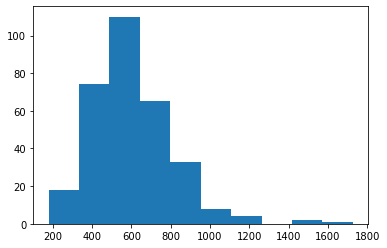

In [25]:
# Plot a simple histogram of the plasma retinol feature
plt.hist(retinol["plasma retinol"])
plt.show()

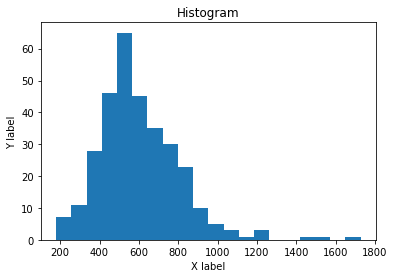

In [26]:
# Redefine the histogram to have 20 bins
plt.hist(retinol["plasma retinol"], bins=20)

# Add a title to the plot
plt.title("Histogram")

# Add other missing parts to the plot
plt.xlabel("X label")
plt.ylabel("Y label")
plt.show()

# Creating boxplots


Let's get back to our heroes dataset. As we previously discovered, the BMI index is in average much higher for villains than for good characters (taking into account only Marvel and DC publishers). Your task is to plot the corresponding distributions of BMI indices using boxplots.


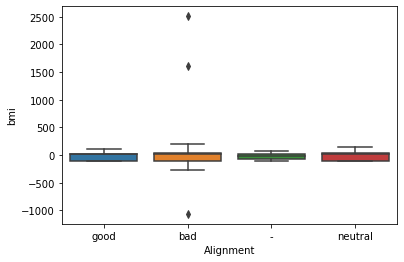

In [30]:
import seaborn as sns

# Create a boxplot of BMI indices for 'good' and 'bad' sides
sns.boxplot( data=heroes, x="Alignment", y = "bmi")
plt.show()

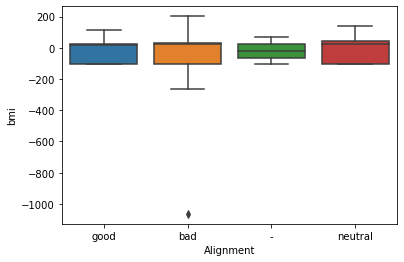

In [31]:
import seaborn as sns

# Select rows from 'heroes' for which the BMI index < 1000
heroes_filtered = heroes[heroes['bmi'] < 1000]

# Create a new boxplot of BMI indices
sns.boxplot( data=heroes_filtered, x="Alignment", y = "bmi")
plt.show()